In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

df = pd.read_csv("../Data/processed/customer_churn_features.csv")

X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

model = joblib.load("../Models/xgboost_model.pkl")

In [2]:
preprocessor = model.named_steps["preprocessor"]
xgb = model.named_steps["model"]

X_transformed = preprocessor.transform(X)

print("Transformed shape:", X_transformed.shape)

Transformed shape: (3000, 31)


In [3]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 31


In [4]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_transformed)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


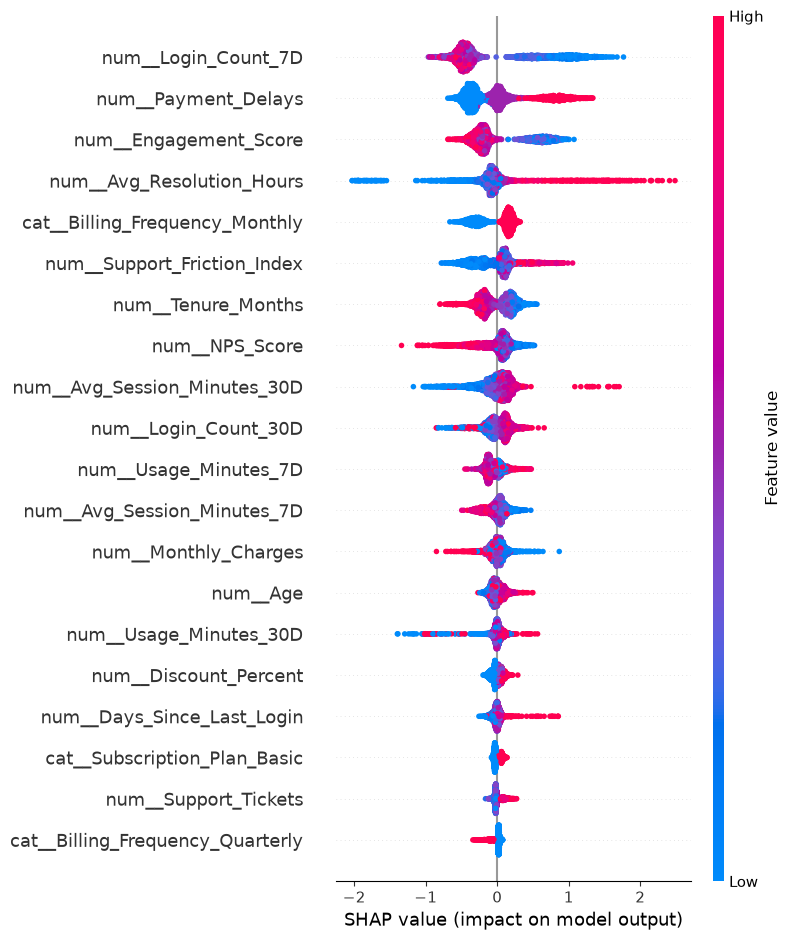

In [5]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)

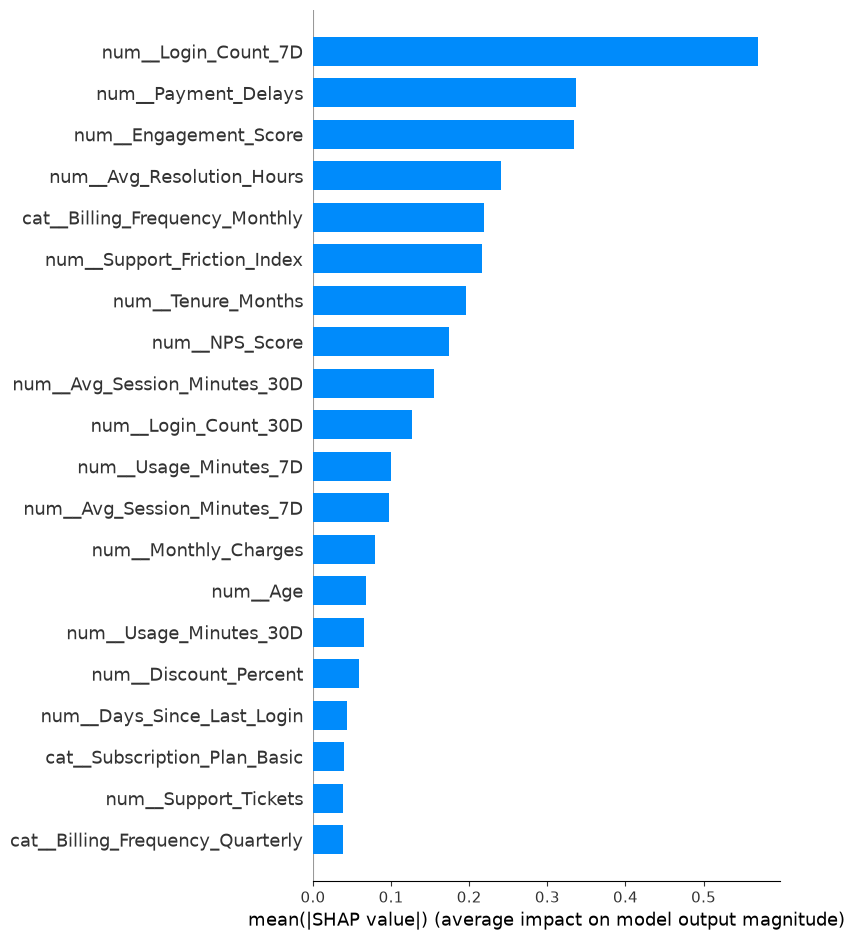

In [6]:
shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

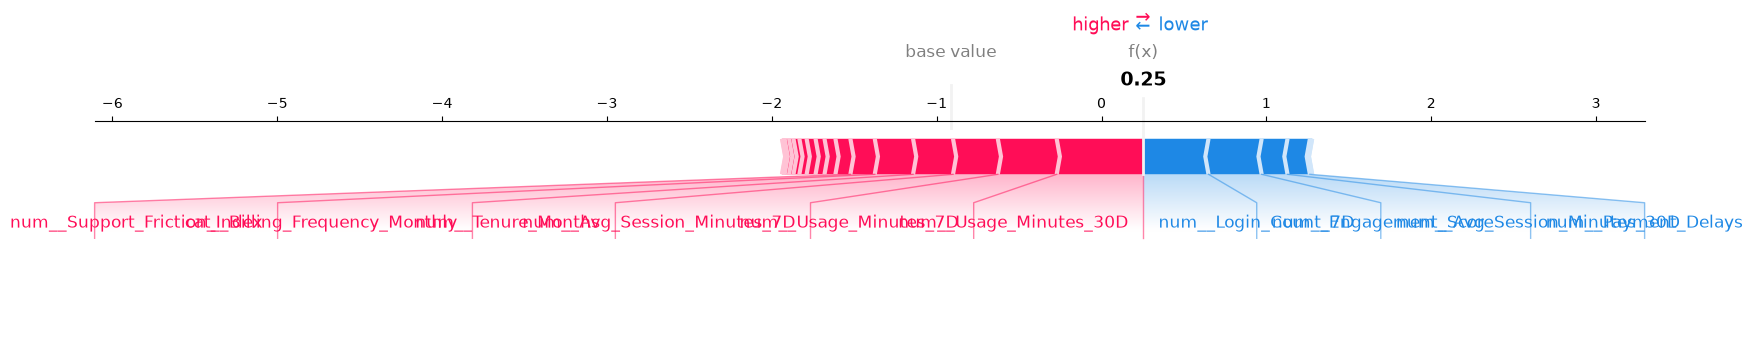

In [7]:
customer_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    feature_names=feature_names,
    matplotlib=True
)

plt.show()

In [8]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": abs(shap_values).mean(axis=0)
})

importance = importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

importance.to_csv(
    "../Reports/shap_feature_importance.csv",
    index=False
)

print("SHAP analysis completed!")

SHAP analysis completed!
